# Main Bearing OpEx Sensitivity Analysis Study
National Renewable Energy Laboratory\
Daniel Mulas Hernando\
28 November 2025

This notebook allows you to specify the random seeds—and thus control the number of simulations—to run for this particular case. For each simulation, it calculates and saves the availability, OpEx, and vessel cost breakdowns. All results are stored in the `library/base_2024/results` folder for easy access and analysis.

In [1]:
import pandas as pd
from pathlib import Path
from wombat.core import Simulation, Metrics

In [2]:
from pathlib import Path
import pandas as pd
from wombat import Simulation, Metrics  # adjust import if needed

def run_windfarm_simulations(technology: str, random_seeds: list, library_path : str, port_name="base_port_139km"):
    """
    Run simulations for a specified wind farm technology and save
    availability, OpEx, vessel costs, and repair time at port.

    Supported technologies:
      - 'fixed_bottom'
      - 'floating'
    
    Parameters:
    - technology: str, one of the supported technology names
    - random_seeds: list of ints, random seeds for reproducibility
    - port_name: str, name of the port to track repair time

    Saves CSV files in library/exxon/results with appropriate naming.
    """

    # === CONFIGURATION ===
    library_path = Path(library_path).resolve()
    results_dir = library_path / "results"
    results_dir.mkdir(parents=True, exist_ok=True)

    # === CONFIG SELECTION ===
    config_map = {
        "ATB3_3_base": "ATB3_3_base.yaml",
        "ATB3_3_base-case-0": "ATB3_3_base-case-0.yaml",
        "ATB3_3_base-case-1": "ATB3_3_base-case-1.yaml",
        "ATB3_3_base-case-2": "ATB3_3_base-case-2.yaml", # 5% in plant lifetime, beta = 1 for major repair
        "ATB3_3_base-case-2b": "ATB3_3_base-case-2b.yaml", # 5% in plant lifetime, beta = 1 for major repair
        "ATB3_3_base-case-3": "ATB3_3_base-case-3.yaml",
    }

    # Validate input
    tech_key = technology
    if tech_key not in config_map:
        raise ValueError(
            f"Invalid technology '{technology}'. Must be one of: "
            f"{', '.join(config_map.keys())}"
        )

    config_name = config_map[tech_key]

    # === STORAGE INITIALIZATION ===
    availability_records = []
    opex_records = []
    vessel_records = []
    repair_time_records = []
    requests_dfs = []
    cost_by_component_dfs = []

    # === RUN SIMULATIONS SEQUENTIALLY ===
    for i, seed in enumerate(random_seeds, start=1):
        print(f"\r🚀 Running simulation {i}/{len(random_seeds)} with seed {seed}...", end="", flush=True)

        # Run simulation
        sim = Simulation(
            library_path=library_path,
            config=config_name,
            random_seed=seed
        )
        sim.run(create_metrics=True, save_metrics_inputs=True)

        # Load metrics
        fpath = sim.env.metrics_input_fname.parent
        fname = sim.env.metrics_input_fname.name
        metrics = Metrics.from_simulation_outputs(fpath, fname)

        # === 1. Availability Results ===
        time_avail = metrics.time_based_availability(frequency="project", by="windfarm")
        prod_avail = metrics.production_based_availability(frequency="project", by="windfarm")
        availability_records.append({
            "run": i,
            "random_seed": seed,
            "time_based_availability": time_avail.iloc[0, 0],
            "production_based_availability": prod_avail.iloc[0, 0],
        })

        # === 2. OpEx Results ===
        opex_df = metrics.opex(frequency="annual", by_category=True).reset_index()
        opex_df.insert(0, "random_seed", seed)
        opex_df.insert(0, "run", i)
        opex_records.append(opex_df)

        # === 3. Vessel Costs ===
        vessel_df = metrics.equipment_costs(frequency="annual", by_equipment=True).reset_index()
        vessel_df.insert(0, "random_seed", seed)
        vessel_df.insert(0, "run", i)
        vessel_records.append(vessel_df)

        # === 4. Repair Time at Port ===
        events_df = sim.env.load_events_log_dataframe()
        events_df['duration'] = pd.to_numeric(events_df['duration'], errors='coerce')
        df_port = events_df[events_df['agent'] == port_name]
        total_hours = df_port['duration'].sum()
        simulation_years = sim.env.end_year - sim.env.start_year + 1
        avg_hours_per_year = total_hours / simulation_years
        avg_days_per_year = avg_hours_per_year / 24
        avg_months_per_year = avg_hours_per_year / (24 * 30.4375)

        repair_time_records.append({
            "run": i,
            "random_seed": seed,
            "avg_repair_time_months": avg_months_per_year,
            "avg_repair_time_days": avg_days_per_year
        })

        # === 4. Requests Summary ===
        requests = metrics.request_summary()
        requests.insert(0, "random_seed", seed)
        requests.insert(0, "run", i)
        requests_dfs.append(requests)

        # === 5. Cost By Component ===
        cost_by_component = metrics.component_costs(frequency="project", by_category=True, by_action=True)
        cost_by_component.insert(0, "random_seed", seed)
        cost_by_component.insert(0, "run", i)
        cost_by_component_dfs.append(cost_by_component)

        
        # Cleanup logs
        sim.env.cleanup_log_files()

    # === COMBINE AND SAVE RESULTS ===
    df_availability = pd.DataFrame(availability_records)
    df_opex = pd.concat(opex_records, ignore_index=True)
    df_vessels = pd.concat(vessel_records, ignore_index=True)
    df_repair_time = pd.DataFrame(repair_time_records)
    df_requests = pd.concat(requests_dfs)
    df_cost_by_component = pd.concat(cost_by_component_dfs)

    df_availability.to_csv(results_dir / f"COWER-2025-{technology}_all_availability_results.csv", index=False)
    df_opex.to_csv(results_dir / f"COWER-2025-{technology}_all_opex_results.csv", index=False)
    df_vessels.to_csv(results_dir / f"COWER-2025-{technology}_all_vessel_results.csv", index=False)
    df_repair_time.to_csv(results_dir / f"COWER-2025-{technology}_repair_time_at_port_results.csv", index=False)
    df_requests.to_csv(results_dir / f"COWER-2025-{technology}_requests_results.csv")
    df_cost_by_component.to_csv(results_dir / f"COWER-2025-{technology}_cost_by_component_results.csv")
    
    print(f"\r✅ All {technology} simulations complete. Results saved to {results_dir}        ")

    return events_df


In [3]:
NUM_RUNS = 25

# Run base ATB case
#sim_ATB3_3_base = run_windfarm_simulations("ATB3_3_base", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run base ATB case with main bearing added as subassembly - case 0 
#sim_ATB3_3_base_case_0 = run_windfarm_simulations("ATB3_3_base-case-0", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 1
#sim_ATB3_3_base_case_1 = run_windfarm_simulations("ATB3_3_base-case-1", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 2
#sim_ATB3_3_base_case_2 = run_windfarm_simulations("ATB3_3_base-case-2", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 2
#sim_ATB3_3_base_case_2b = run_windfarm_simulations("ATB3_3_base-case-2b", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 3
sim_ATB3_3_base_case_3 = run_windfarm_simulations("ATB3_3_base-case-3", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

✅ All ATB3_3_base-case-3 simulations complete. Results saved to C:\GE-main-bearing\WOMBAT\library\base_2023\results        


## Summarize Results from Multiple Simulations in One Table

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

def summarize_simulation(library_path="../library/base_2023/results/"):
    """
    Compute average and std results per technology across all simulation runs,
    producing a formatted summary table in $/kW-yr, %, and port repair times.
    """

    # === Project capacities (MW) per technology ===
    project_capacities_mw = {
        "ATB3_3_base-case-0": 201.3,
        "ATB3_3_base-case-1": 201.3,
        "ATB3_3_base-case-2": 201.3,
        "ATB3_3_base-case-2b": 201.3,
        "ATB3_3_base-case-3": 201.3,
    }

    technologies = list(project_capacities_mw.keys())
    summary_dict = {}

    # Step 1: Collect all vessel columns across all techs
    vessel_cols_all = set()
    for tech in technologies:
        df_vessels = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_vessel_results.csv")
        vessel_cols = [c for c in df_vessels.columns if c not in ["run", "random_seed", "year"]]
        vessel_cols_all.update(vessel_cols)
    vessel_cols_all = sorted(vessel_cols_all)

    # Step 2: Process each technology
    for tech in technologies:
        capacity_kw = project_capacities_mw[tech] * 1_000  # MW → kW

        df_avail = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_availability_results.csv")
        df_opex = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_opex_results.csv")
        df_vessels = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_vessel_results.csv")

        # === Availability ===
        summary_dict.setdefault("avg_time_based_availability", {})[f"{tech} Mean"] = df_avail["time_based_availability"].mean() * 100
        summary_dict["avg_time_based_availability"][f"{tech} Std"] = df_avail["time_based_availability"].std() * 100

        summary_dict.setdefault("avg_production_based_availability", {})[f"{tech} Mean"] = df_avail["production_based_availability"].mean() * 100
        summary_dict["avg_production_based_availability"][f"{tech} Std"] = df_avail["production_based_availability"].std() * 100

        # === OpEx by category ===
        opex_cols = ["operations", "port_fees", "total_labor_cost", "materials_cost"]
        for col in opex_cols:
            if col in df_opex.columns:
                summary_dict.setdefault(col, {})[f"{tech} Mean"] = df_opex[col].mean() / capacity_kw
                summary_dict[col][f"{tech} Std"] = df_opex[col].std() / capacity_kw
            else:
                summary_dict.setdefault(col, {})[f"{tech} Mean"] = np.nan
                summary_dict[col][f"{tech} Std"] = np.nan

        # === Vessel Costs ===
        vessel_total = df_vessels[[c for c in vessel_cols_all if c in df_vessels.columns]].sum(axis=1)
        summary_dict.setdefault("equipment_cost", {})[f"{tech} Mean"] = vessel_total.mean() / capacity_kw
        summary_dict["equipment_cost"][f"{tech} Std"] = vessel_total.std() / capacity_kw

        for col in vessel_cols_all:
            key = f"  - {col}"
            if col in df_vessels.columns:
                summary_dict.setdefault(key, {})[f"{tech} Mean"] = df_vessels[col].mean() / capacity_kw
                summary_dict[key][f"{tech} Std"] = df_vessels[col].std() / capacity_kw
            else:
                summary_dict.setdefault(key, {})[f"{tech} Mean"] = np.nan
                summary_dict[key][f"{tech} Std"] = np.nan

        # === Total OpEx ===
        valid_opex = [col for col in opex_cols if col in df_opex.columns]
        op_ex_total = df_opex[valid_opex].sum(axis=1) + vessel_total
        summary_dict.setdefault("OpEx_total", {})[f"{tech} Mean"] = op_ex_total.mean() / capacity_kw
        summary_dict["OpEx_total"][f"{tech} Std"] = op_ex_total.std() / capacity_kw

    # === Build DataFrame ===
    df_summary = pd.DataFrame(summary_dict).T

    # Row ordering
    avail_rows = ["avg_time_based_availability", "avg_production_based_availability"]
    opex_rows = ["operations", "port_fees", "total_labor_cost", "materials_cost"]
    vessel_rows = ["equipment_cost"] + [f"  - {v}" for v in vessel_cols_all]
    ordered_rows = avail_rows + opex_rows + vessel_rows + ["OpEx_total"]
    df_summary = df_summary.loc[ordered_rows]

    # === Add Project Capacity row ===
    project_capacity_data = {}
    for col in df_summary.columns:
        if "Mean" in col:
            tech_name = col.replace(" Mean", "")
            project_capacity_data[col] = project_capacities_mw.get(tech_name, "-")
        elif "Std" in col:
            project_capacity_data[col] = "-"
        else:
            project_capacity_data[col] = np.nan

    project_capacity_row = pd.DataFrame([project_capacity_data], index=["Project Capacity"])

    # === Add Units column ===
    if "Units" not in df_summary.columns:
        df_summary.insert(0, "Units", np.nan)

    df_summary.loc[:, "Units"] = df_summary.index.map({
        "avg_time_based_availability": "%",
        "avg_production_based_availability": "%",
        "operations": "$ / kW-yr",
        "port_fees": "$ / kW-yr",
        "total_labor_cost": "$ / kW-yr",
        "materials_cost": "$ / kW-yr",
        "equipment_cost": "$ / kW-yr",
        "OpEx Total": "$ / kW-yr",
        "OpEx_total": "$ / kW-yr",
    }).fillna("$ / kW-yr")

    project_capacity_row.insert(0, "Units", "MW")

    # === Combine Project Capacity and main table ===
    df_summary = pd.concat([project_capacity_row, df_summary], axis=0)

    # === Formatting ===
    df_summary.columns = [col.replace("_", " ").title() for col in df_summary.columns]
    df_summary.index = df_summary.index.str.replace("_", " ").str.title()

    # Round all numeric values (mean & std) to 1 decimal
    df_summary = df_summary.applymap(
        lambda x: f"{x:.3f}" if isinstance(x, (int, float, np.number)) and not pd.isna(x) else x
    )

    df_summary.replace(0, np.nan, inplace=True)
    df_summary.fillna("-", inplace=True)

    # Keep Project Capacity even if all other values are "-"
    mean_cols = [c for c in df_summary.columns if "Mean" in c]
    std_cols = [c for c in df_summary.columns if "Std" in c]
    df_summary = df_summary[
        ~((df_summary[mean_cols + std_cols].eq("-").all(axis=1)) & (df_summary.index != "Project Capacity"))
    ]

    return df_summary


In [5]:
summarize_simulation()

C:\Users\dmulash\AppData\Local\Temp\1\ipykernel_24944\1672267912.py:103: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Index(['%', '%', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr',
       '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr',
       '$ / kW-yr', '$ / kW-yr', '$ / kW-yr'],
      dtype='object')' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_summary.loc[:, "Units"] = df_summary.index.map({
C:\Users\dmulash\AppData\Local\Temp\1\ipykernel_24944\1672267912.py:125: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_summary = df_summary.applymap(


,Units,Atb3 3 Base-Case-0 Mean,Atb3 3 Base-Case-0 Std,Atb3 3 Base-Case-1 Mean,Atb3 3 Base-Case-1 Std,Atb3 3 Base-Case-2 Mean,Atb3 3 Base-Case-2 Std,Atb3 3 Base-Case-2B Mean,Atb3 3 Base-Case-2B Std,Atb3 3 Base-Case-3 Mean,Atb3 3 Base-Case-3 Std
Project Capacity,MW,201.300,-,201.300,-,201.300,-,201.300,-,201.300,-
Avg Time Based Availability,%,95.745,0.221,96.052,0.052,96.054,0.059,96.038,0.052,96.054,0.043
Avg Production Based Availability,%,91.281,0.337,91.639,0.290,91.613,0.371,91.615,0.364,91.605,0.363
Operations,$ / kW-yr,25.376,0.029,25.376,0.029,25.376,0.029,25.376,0.029,25.376,0.029
Port Fees,$ / kW-yr,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Total Labor Cost,$ / kW-yr,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Materials Cost,$ / kW-yr,8.597,2.540,6.142,1.345,6.337,1.405,6.554,1.787,6.783,2.881
Equipment Cost,$ / kW-yr,8.730,0.982,8.191,0.567,8.240,0.571,8.313,0.660,8.234,0.575
- Large Crane 1,$ / kW-yr,5.905,0.806,5.969,0.790,5.879,0.810,5.881,0.839,5.874,0.825
- Large Crane 2,$ / kW-yr,2.175,1.026,2.114,1.029,2.219,1.014,2.204,1.043,2.216,1.039


In [6]:
# === CONFIGURATION ===
library_path = Path("../library/base_2023/").resolve()
results_dir = library_path / "results"
summarize_simulation().to_csv(results_dir / f"summary_opex_results_all_cases.csv")

C:\Users\dmulash\AppData\Local\Temp\1\ipykernel_24944\1672267912.py:103: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Index(['%', '%', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr',
       '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr',
       '$ / kW-yr', '$ / kW-yr', '$ / kW-yr'],
      dtype='object')' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_summary.loc[:, "Units"] = df_summary.index.map({
C:\Users\dmulash\AppData\Local\Temp\1\ipykernel_24944\1672267912.py:125: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_summary = df_summary.applymap(


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

def plot_opex_availability_summary(library_path="../library/base_2023/results/"):
    """
    Create a stacked bar + box plot showing OpEx composition and availability variability
    across simulation cases, avoiding double-counting vessel costs.
    """

    # === Configuration ===
    technologies = [
        "ATB3_3_base-case-0",
        "ATB3_3_base-case-1",
        "ATB3_3_base-case-1",
        "ATB3_3_base-case-2",
        "ATB3_3_base-case-2b",
        "ATB3_3_base-case-3",
    ]
    labels = ["Baseline", "Miba #1", "Miba #1b", "Miba #2", "Miba #2b", "Miba #3"]

    # Professional color palette
    colors = {
        "operations": "#4E79A7",
        "port_fees": "#F28E2B",
        "total_labor_cost": "#E15759",
        "materials_cost": "#76B7B2",
        "equipment_cost": "#59A14F",
    }
    opex_cols = ["operations", "port_fees", "total_labor_cost", "materials_cost"]

    # === Prepare containers ===
    opex_means = {col: [] for col in colors.keys()}
    opex_stds = []
    avail_data = []
    total_opex_runs = []

    # === Loop through technologies ===
    for tech in technologies:
        cap_mw = 201.3
        cap_kw = cap_mw * 1_000

        df_opex = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_opex_results.csv")
        df_vessels = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_vessel_results.csv")
        df_avail = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_availability_results.csv")

        # --- OpEx by category ---
        for col in opex_cols:
            if col in df_opex.columns:
                opex_means[col].append(df_opex[col].mean() / cap_kw)
            else:
                opex_means[col].append(0)

        # --- Vessel total cost (not double counted) ---
        vessel_cols = [c for c in df_vessels.columns if c not in ["run", "random_seed", "year"]]
        vessel_total = df_vessels[vessel_cols].sum(axis=1)
        equipment_mean = vessel_total.mean() / cap_kw
        opex_means["equipment_cost"].append(equipment_mean)

        # --- Total OpEx variability ---
        valid_opex = [col for col in opex_cols if col in df_opex.columns]
        total_opex = df_opex[valid_opex].sum(axis=1) + vessel_total
        total_opex_runs.append(total_opex / cap_kw)
        opex_stds.append(total_opex.std() / cap_kw)

        # --- Availability data ---
        avail_data.append(df_avail["time_based_availability"] * 100)

    # === Plotting ===
    fig, ax1 = plt.subplots(figsize=(10, 6))
    x = np.arange(len(technologies))
    bottom = np.zeros(len(technologies))

    # Remove categories with all zeros
    nonzero_categories = [col for col, vals in opex_means.items() if np.any(np.array(vals) != 0)]

    # --- Stacked bars ---
    for col in nonzero_categories:
        ax1.bar(
            x,
            opex_means[col],
            bottom=bottom,
            label=col.replace("_", " ").title(),
            color=colors[col],
            edgecolor="black",
            linewidth=0.8
        )
        bottom += np.array(opex_means[col])

    # --- Error bars ---
    ax1.errorbar(x, bottom, yerr=opex_stds, fmt='k_', capsize=5, label='Total OpEx Std')

    # --- Text labels (above error bar) ---
    for i, total in enumerate(bottom):
        n_runs = len(total_opex_runs[i])
        upper = total + opex_stds[i]  # top of error bar
        ax1.text(
            x[i],
            upper + 1.5,
            f"{total:.1f}\n(n={n_runs})",
            ha='center',
            va='bottom',
            fontsize=8,
            color='black'
        )

    # === Secondary axis: Availability boxplots ===
    ax2 = ax1.twinx()
    boxprops = dict(facecolor='maroon', alpha=0.3, color='maroon')
    medianprops = dict(color='maroon')
    whiskerprops = dict(color='maroon')
    capprops = dict(color='maroon')
    flierprops = dict(marker='o', markersize=4, markerfacecolor='maroon', markeredgecolor='maroon', alpha=0.5)

    ax2.boxplot(
        avail_data,
        positions=x,
        widths=0.3,
        patch_artist=True,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        flierprops=flierprops
    )

    # --- Add mean availability in red ---
    for i, data in enumerate(avail_data):
        mean_val = data.mean()
        ax2.text(
            x[i] + 0.17, mean_val, f"{mean_val:.1f}%",
            color='maroon', fontsize=8, va='center', ha='left', fontweight='bold'
        )

    # === Axis formatting ===
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.set_xlabel("Scenario")
    ax1.set_ylabel("OpEx ($/kW-yr)")
    ax2.set_ylabel("Time-Based Availability (%)", color='maroon')
    ax2.tick_params(axis='y', colors='maroon')

    ax1.set_ylim(0, 73)
    ax2.set_ylim(94.4, 96.3)

    ax1.set_title("OpEx and Availability Summary by Scenario")
    ax1.legend(loc='upper left', bbox_to_anchor=(1.07, 1))
    ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

    # === Save figure ===
    os.makedirs("Figures", exist_ok=True)
    plt.tight_layout()
    plt.savefig("Figures/OpEx_Availability_Summary.png", dpi=300)
    plt.show()


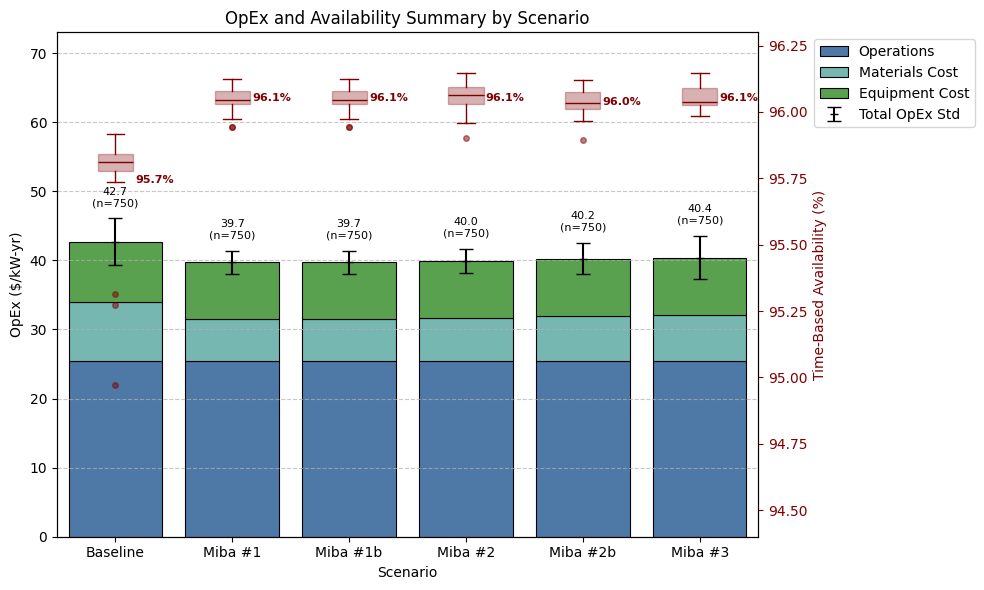

In [8]:
plot_opex_availability_summary()

sim_ATB3_3_base_case_0.to_csv("case-0-events.csv")

sim_ATB3_3_base_case_1.to_csv("case-1-events.csv")

In [9]:
import pandas as pd
from pathlib import Path
from functools import reduce

def summarize_main_bearing_requests_report(library_path="../library/base_2023/results/"):
    """
    Summarize main bearing requests in a report-style table:
    Rows = task + request type, Columns = scenarios.
    Averages over multiple simulations in each CSV.
    """

    scenarios = [
        "ATB3_3_base-case-0",
        "ATB3_3_base-case-1",
        "ATB3_3_base-case-2",
        "ATB3_3_base-case-2b",
        "ATB3_3_base-case-3",
    ]

    request_cols = ['total_requests', 'canceled_requests', 'incomplete_requests', 'completed_requests']

    scenario_dfs = {}

    for scenario in scenarios:
        file_path = Path(library_path) / f"COWER-2025-{scenario}_requests_results.csv"
        df = pd.read_csv(file_path)

        # Filter for all main-bearing–related subassemblies
        df_mb = df[df['subassembly'].isin([
            'main_bearing_maintenance',
            'main_bearing_failures',
            'main_bearing'
        ])]

        # Group by task + request_type and average numerical columns
        df_avg = df_mb.groupby('task')[request_cols].mean().reset_index()

        # Melt so that request type becomes a column
        df_melt = df_avg.melt(id_vars=['task'], value_vars=request_cols,
                              var_name='request_type', value_name=scenario)

        scenario_dfs[scenario] = df_melt

    # Merge all scenarios on task + request_type
    df_summary = reduce(lambda left, right: pd.merge(left, right, on=['task', 'request_type'], how='outer'),
                        scenario_dfs.values())

    # Optional: sort by task then request_type
    df_summary = df_summary.sort_values(['task', 'request_type']).reset_index(drop=True)

    return df_summary


In [10]:
summarize_main_bearing_requests_report()

,task,request_type,ATB3_3_base-case-0,ATB3_3_base-case-1,ATB3_3_base-case-2,ATB3_3_base-case-2b,ATB3_3_base-case-3
0,major repair,canceled_requests,NaN,0.00,0.000000,0.000000,0.000000
1,major repair,completed_requests,NaN,15.48,14.880000,14.840000,15.080000
2,major repair,incomplete_requests,NaN,0.00,0.000000,0.000000,0.040000
3,major repair,total_requests,NaN,15.48,14.880000,14.840000,15.120000
4,major replacement,canceled_requests,0.00,NaN,0.000000,0.000000,0.000000
5,major replacement,completed_requests,13.72,NaN,1.333333,3.173913,1.333333
6,major replacement,incomplete_requests,0.12,NaN,0.000000,0.043478,0.066667
7,major replacement,total_requests,13.84,NaN,1.333333,3.217391,1.400000
8,major scheduled repair,canceled_requests,NaN,NaN,NaN,NaN,0.000000
9,major scheduled repair,completed_requests,NaN,NaN,NaN,NaN,61.000000


In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

def summarize_large_crane_costs(library_path="../library/base_2023/results/"):
    scenarios = [
        "ATB3_3_base-case-0",
        "ATB3_3_base-case-1",
        "ATB3_3_base-case-2",
        "ATB3_3_base-case-2b",
        "ATB3_3_base-case-3",
    ]

    results = {}

    for scenario in scenarios:
        df_v = pd.read_csv(Path(library_path) / f"COWER-2025-{scenario}_all_vessel_results.csv")

        # ---- FIND THE ACTUAL COLUMN NAME ----
        possible_cols = [
            c for c in df_v.columns
            if "large" in c.lower() and "crane" in c.lower() and "mb" in c.lower()
        ]

        if len(possible_cols) == 0:
            results[scenario] = np.nan
            continue

        col = possible_cols[0]  # the matched column

        results[scenario] = df_v[col].mean()

    return pd.DataFrame([results], index=["Large Crane For MB Cost"])


def add_large_crane_cost_to_mb_table(df_mb, df_crane):
    """
    Append Large Crane For MB average cost to the main-bearing summary table.
    df_mb     = output of summarize_main_bearing_requests_report()
    df_crane  = DataFrame with one row: index = 'Large Crane For MB Cost'
                and columns = scenario costs
    """

    # Build an empty row with all columns from df_mb
    new_row = {col: np.nan for col in df_mb.columns}

    # Required ID columns
    new_row["task"] = "major replacement"
    new_row["request_type"] = "Large Crane For MB Cost"

    # Fill scenario columns
    for scenario in df_crane.columns:
        if scenario in new_row:
            new_row[scenario] = df_crane.at["Large Crane For MB Cost", scenario]

    # Append row
    df_final = pd.concat([df_mb, pd.DataFrame([new_row])], ignore_index=True)

    return df_final


    return df_final


In [12]:
# Step 1: create the combined table
df = add_large_crane_cost_to_mb_table(
    summarize_main_bearing_requests_report(library_path="../library/base_2023/results/"),
    summarize_large_crane_costs(library_path="../library/base_2023/results/")
)

# Step 2: keep only "major replacement" tasks
df_filtered = df[df['task'] == "major replacement"].reset_index(drop=True)

df_filtered

,task,request_type,ATB3_3_base-case-0,ATB3_3_base-case-1,ATB3_3_base-case-2,ATB3_3_base-case-2b,ATB3_3_base-case-3
0,major replacement,canceled_requests,0.000000,NaN,0.000000,0.000000,0.000000
1,major replacement,completed_requests,13.720000,NaN,1.333333,3.173913,1.333333
2,major replacement,incomplete_requests,0.120000,NaN,0.000000,0.043478,0.066667
3,major replacement,total_requests,13.840000,NaN,1.333333,3.217391,1.400000
4,major replacement,Large Crane For MB Cost,109030.936592,NaN,11333.011139,25941.395009,11580.753431


In [13]:
sim_ATB3_3_base_case_3.to_csv("case-3-events.csv")

In [14]:
NUM_RUNS = 1
# Run case 3
sim_ATB3_3_base_case_3 = run_windfarm_simulations("ATB3_3_base-case-3", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

✅ All ATB3_3_base-case-3 simulations complete. Results saved to C:\GE-main-bearing\WOMBAT\library\base_2023\results        


In [15]:
sim_ATB3_3_base_case_3.to_csv("case-3-events.csv")

In [16]:
summarize_main_bearing_requests_report()

,task,request_type,ATB3_3_base-case-0,ATB3_3_base-case-1,ATB3_3_base-case-2,ATB3_3_base-case-2b,ATB3_3_base-case-3
0,major repair,canceled_requests,NaN,0.00,0.000000,0.000000,0.0
1,major repair,completed_requests,NaN,15.48,14.880000,14.840000,15.0
2,major repair,incomplete_requests,NaN,0.00,0.000000,0.000000,0.0
3,major repair,total_requests,NaN,15.48,14.880000,14.840000,15.0
4,major replacement,canceled_requests,0.00,NaN,0.000000,0.000000,0.0
5,major replacement,completed_requests,13.72,NaN,1.333333,3.173913,1.0
6,major replacement,incomplete_requests,0.12,NaN,0.000000,0.043478,0.0
7,major replacement,total_requests,13.84,NaN,1.333333,3.217391,1.0
8,major scheduled repair,canceled_requests,NaN,NaN,NaN,NaN,0.0
9,major scheduled repair,completed_requests,NaN,NaN,NaN,NaN,61.0
